In [ ]:
# SECTION 1 - Data cleaning

In [ ]:
!pip install -U -q PyDrive2
!apt install openjdk-17-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

openjdk-17-jdk-headless is already the newest version (17.0.18+8-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from google.colab import auth, files
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from oauth2client.client import GoogleCredentials

# authenticate and create the PyDrive client
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Traffic_Crashes_-_Crashes_20260405.csv')
df.info()
df.head()


/tmp/ipykernel_1408/2131781438.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Traffic_Crashes_-_Crashes_20260405.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040008 entries, 0 to 1040007
Data columns (total 48 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   CRASH_RECORD_ID                1040008 non-null  object 
 1   CRASH_DATE_EST_I               75410 non-null    object 
 2   CRASH_DATE                     1040008 non-null  object 
 3   POSTED_SPEED_LIMIT             1040008 non-null  int64  
 4   TRAFFIC_CONTROL_DEVICE         1040008 non-null  object 
 5   DEVICE_CONDITION               1040008 non-null  object 
 6   WEATHER_CONDITION              1040008 non-null  object 
 7   LIGHTING_CONDITION             1040008 non-null  object 
 8   FIRST_CRASH_TYPE               1040008 non-null  object 
 9   TRAFFICWAY_TYPE                1040008 non-null  object 
 10  LANE_CNT                       199041 non-null   object 
 11  ALIGNMENT                      1040008 non-null  object 
 12  ROADWAY_SURFAC

,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,...,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,NaN,03/26/2026 01:10:00 AM,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,FOUR WAY,...,2.0,0.0,0.0,0.0,1,5,3,41.889034,-87.652384,POINT (-87.652383794854 41.889033593623)
1,a54653293da79b801c24a0f649d0579c804ec29783ec58...,NaN,03/26/2026 12:50:00 AM,30,STOP SIGN/FLASHER,UNKNOWN,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,FOUR WAY,...,0.0,0.0,3.0,0.0,0,5,3,41.970192,-87.724604,POINT (-87.724603633832 41.970191905164)
2,3c086a26f6a68215c61ea414a60ec4e230937bea80b615...,NaN,03/25/2026 11:19:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,DUSK,PARKED MOTOR VEHICLE,NOT DIVIDED,...,0.0,0.0,1.0,0.0,23,4,3,41.775935,-87.590371,POINT (-87.590370976328 41.775935242789)
3,a6917d7f5474cc478e1b7b3113c514658d2a26eba5c1a8...,NaN,03/25/2026 11:02:00 PM,30,STOP SIGN/FLASHER,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",ANGLE,FOUR WAY,...,0.0,0.0,2.0,0.0,23,4,3,41.943359,-87.806793,POINT (-87.806793335324 41.943358539021)
4,50f55aa05e47ba33a9cac07e334a67603672ede52d2577...,NaN,03/25/2026 10:10:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,SIDESWIPE SAME DIRECTION,NOT DIVIDED,...,0.0,0.0,2.0,0.0,22,4,3,41.918066,-87.668144,POINT (-87.668144487826 41.918066048906)


In [ ]:
# check for types of columns
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if col not in cat_cols]

print(cat_cols)
print(num_cols)

print('BEFORE " LAST_UPDATED" CONVERTED TO DATETIME')
print()

df.info()

# converted " LAST_UPDATED" column to datetime
df['CRASH_DATE'] = pd.to_datetime(df['CRASH_DATE'])
print()
print('AFTER " LAST_UPDATED" CONVERTED TO DATETIME')
print()
df.info()


['CRASH_RECORD_ID', 'CRASH_DATE_EST_I', 'CRASH_DATE', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'LANE_CNT', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'INTERSECTION_RELATED_I', 'NOT_RIGHT_OF_WAY_I', 'HIT_AND_RUN_I', 'DAMAGE', 'DATE_POLICE_NOTIFIED', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_DIRECTION', 'STREET_NAME', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I', 'MOST_SEVERE_INJURY', 'LOCATION']
['POSTED_SPEED_LIMIT', 'STREET_NO', 'BEAT_OF_OCCURRENCE', 'NUM_UNITS', 'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'LATITUDE', 'LONGITUDE']
BEFORE " LAST_UPDATED" CONVERTED TO DATETIME

<class 'pandas.core.frame.DataFr

In [ ]:
# checks for are any duplicates in the data
duplicate_check = df.duplicated()
for i in range(len(duplicate_check)):
  if duplicate_check[i] == True:
    print("Duplicate found at index", i)
    break
print("Done checking for duplicates")

Done checking for duplicates


In [ ]:
# check for null values
round((df.isnull().sum() / df.shape[0]) * 100, 2)

,0
CRASH_RECORD_ID,0.00
CRASH_DATE_EST_I,92.75
CRASH_DATE,0.00
POSTED_SPEED_LIMIT,0.00
TRAFFIC_CONTROL_DEVICE,0.00
DEVICE_CONDITION,0.00
WEATHER_CONDITION,0.00
LIGHTING_CONDITION,0.00
FIRST_CRASH_TYPE,0.00
TRAFFICWAY_TYPE,0.00


In [ ]:
# renaming all columns and converting names into lowercase
df.columns = df.columns.str.strip().str.lower()

# drop "comments" column
df = df.drop(columns=['crash_date_est_i'])
df.info()

# create year column
df['year'] = df['crash_date'].dt.year
df.info()
df.head()
df['lane_cnt'] = df['lane_cnt'].fillna(-1)

df['lane_cnt'].unique()

df['lane_cnt'] = df['lane_cnt'].fillna(0.0)
df['intersection_related_i'] = df['intersection_related_i'].fillna('Unsure')
df['not_right_of_way_i'] = df['not_right_of_way_i'].fillna('Unsure')
df['hit_and_run_i'] = df['hit_and_run_i'].fillna('Unsure')
df['photos_taken_i'] = df['photos_taken_i'].fillna('Unsure')

cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if col not in cat_cols]

for col in cat_cols:
  df[col] = df[col].fillna('Unsure')
df.info()

print(cat_cols)
print(num_cols)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040008 entries, 0 to 1040007
Data columns (total 47 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   crash_record_id                1040008 non-null  object        
 1   crash_date                     1040008 non-null  datetime64[ns]
 2   posted_speed_limit             1040008 non-null  int64         
 3   traffic_control_device         1040008 non-null  object        
 4   device_condition               1040008 non-null  object        
 5   weather_condition              1040008 non-null  object        
 6   lighting_condition             1040008 non-null  object        
 7   first_crash_type               1040008 non-null  object        
 8   trafficway_type                1040008 non-null  object        
 9   lane_cnt                       199041 non-null   object        
 10  alignment                      1040008 non-null  objec

In [ ]:
# get entries from 2025
cond = df['year'] >= 2025
df = df.where(cond)
df.dropna(inplace=True)
df.sort_values(by='crash_date', inplace=True)
df

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131637 entries, 133283 to 0
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   crash_record_id                131637 non-null  object        
 1   crash_date                     131637 non-null  datetime64[ns]
 2   posted_speed_limit             131637 non-null  float64       
 3   traffic_control_device         131637 non-null  object        
 4   device_condition               131637 non-null  object        
 5   weather_condition              131637 non-null  object        
 6   lighting_condition             131637 non-null  object        
 7   first_crash_type               131637 non-null  object        
 8   trafficway_type                131637 non-null  object        
 9   lane_cnt                       131637 non-null  object        
 10  alignment                      131637 non-null  object        
 11  roadw

In [ ]:
# sort by last_updated
df = df.sort_values(by='crash_date')
df.info()
df
df.to_csv('/content/drive/MyDrive/Traffic_Crashes_Cleaned_2026.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 131637 entries, 133283 to 0
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   crash_record_id                131637 non-null  object        
 1   crash_date                     131637 non-null  datetime64[ns]
 2   posted_speed_limit             131637 non-null  float64       
 3   traffic_control_device         131637 non-null  object        
 4   device_condition               131637 non-null  object        
 5   weather_condition              131637 non-null  object        
 6   lighting_condition             131637 non-null  object        
 7   first_crash_type               131637 non-null  object        
 8   trafficway_type                131637 non-null  object        
 9   lane_cnt                       131637 non-null  object        
 10  alignment                      131637 non-null  object        
 11  roadw

In [ ]:
# SECTION 2 - Decision Tree

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# double checking to see if we have all the right columns
print(df.columns.to_list())
print(df.shape)

['crash_record_id', 'crash_date', 'posted_speed_limit', 'traffic_control_device', 'device_condition', 'weather_condition', 'lighting_condition', 'first_crash_type', 'trafficway_type', 'lane_cnt', 'alignment', 'roadway_surface_cond', 'road_defect', 'report_type', 'crash_type', 'intersection_related_i', 'not_right_of_way_i', 'hit_and_run_i', 'damage', 'date_police_notified', 'prim_contributory_cause', 'sec_contributory_cause', 'street_no', 'street_direction', 'street_name', 'beat_of_occurrence', 'photos_taken_i', 'statements_taken_i', 'dooring_i', 'work_zone_i', 'work_zone_type', 'workers_present_i', 'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_reported_not_evident', 'injuries_no_indication', 'injuries_unknown', 'crash_hour', 'crash_day_of_week', 'crash_month', 'latitude', 'longitude', 'location', 'year']
(131637, 48)


In [ ]:
# creating target variables where:
# 0 = non-severe
# 1 = minor injury crash
# 2 = fatal crash

def severity_label(row):
  if row['injuries_fatal'] > 0:
    return 2
  elif row['injuries_total'] > 0:
    return 1
  else:
    return 0

df['severity_label'] = df.apply(severity_label, axis=1)


print(df['severity_label'].value_counts()) #prints the number of accidents in each class

severity_label
0    110256
1     21276
2       105
Name: count, dtype: int64


In [ ]:
# choosing the input features
# we did not include:
# injuries_total
# injuries_fatal
# injuries_incapacitating
# injuries_non_incapacitating
# most_severe_injury
# because those will tell us the outcome already

feature_cols = [
    'posted_speed_limit',
    'traffic_control_device',
    'device_condition',
    'weather_condition',
    'lighting_condition',
    'first_crash_type',
    'trafficway_type',
    'alignment',
    'roadway_surface_cond',
    'road_defect',
    'crash_hour',
    'crash_day_of_week',
    'crash_month',
    'latitude',
    'longitude'
]

tree = df[feature_cols + ['severity_label']].copy()
tree = tree.dropna()

print(tree.shape)

(131637, 16)


In [ ]:
# split into x and y

X = tree[feature_cols]
y = tree['severity_label']

In [ ]:
# convert categorical data into numerical data

X_encoded = pd.get_dummies(X, drop_first=False)

print(X_encoded.shape)

(131637, 108)


In [ ]:
# training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("training set:", X_train.shape)
print("testing set:", X_test.shape)

training set: (105309, 108)
testing set: (26328, 108)


In [ ]:
# build decsion tree model and train the model

model = DecisionTreeClassifier(random_state=42, max_depth=8, class_weight='balanced')
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

In [ ]:
# predictions
y_pred = model.predict(X_test)

In [ ]:
# evaluate model

print("accuracy:")
print(accuracy_score(y_test, y_pred))
print()

print("confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("classification Report:")
print(classification_report(y_test, y_pred))

accuracy:
0.7239820723184442

confusion Matrix:
[[17246  3800   939]
 [ 2098  1803   415]
 [    2    13    12]]

classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83     21985
           1       0.32      0.42      0.36      4316
           2       0.01      0.44      0.02        27

    accuracy                           0.72     26328
   macro avg       0.41      0.55      0.40     26328
weighted avg       0.80      0.72      0.76     26328



In [ ]:
# important features

important_features = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 15 Most Important Features:")
print(important_features.head(15))

Top 15 Most Important Features:
                                      feature  importance
1                                  crash_hour    0.245975
57      first_crash_type_PARKED MOTOR VEHICLE    0.149607
59                first_crash_type_PEDESTRIAN    0.112636
4                                    latitude    0.090825
5                                   longitude    0.082767
65  first_crash_type_SIDESWIPE SAME DIRECTION    0.039702
0                          posted_speed_limit    0.033718
3                                 crash_month    0.033234
9          traffic_control_device_NO CONTROLS    0.031307
58              first_crash_type_PEDALCYCLIST    0.030492
52              first_crash_type_FIXED OBJECT    0.023937
99               roadway_surface_cond_UNKNOWN    0.021953
20   traffic_control_device_STOP SIGN/FLASHER    0.018368
50                     first_crash_type_ANGLE    0.016797
2                           crash_day_of_week    0.011374


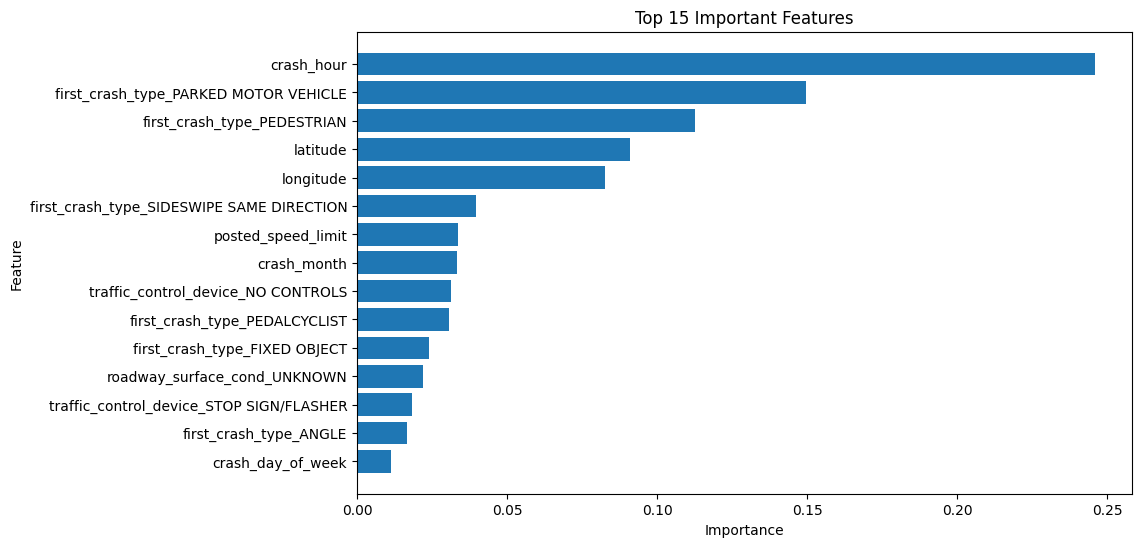

In [ ]:
# plot important features
plt.figure(figsize=(10, 6))
plt.barh(
    important_features['feature'].head(15)[::-1],
    important_features['importance'].head(15)[::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")
plt.show()


In [ ]:
# Section 3 - K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# clustered using latitude and longitude which will help treat each crash as a point in Euclidean space

kmeans_df = df[['latitude', 'longitude', 'severity_label']].dropna().copy()

# remove any invalid coordinates
kmeans_df = kmeans_df[
    (kmeans_df['latitude'] != 0) &
    (kmeans_df['longitude'] != 0) &
    (kmeans_df['latitude'].between(41, 43)) &
    (kmeans_df['longitude'].between(-89, -87))
]

print(kmeans_df[['latitude', 'longitude']].describe())

print("K-means dataframe shape:", kmeans_df.shape)
print(kmeans_df.head())

            latitude      longitude
count  131623.000000  131623.000000
mean       41.860583     -87.680115
std         0.086295       0.059065
min        41.644613     -87.939678
25%        41.788246     -87.721578
50%        41.876787     -87.675675
75%        41.927995     -87.635548
max        42.022780     -87.524587
K-means dataframe shape: (131623, 3)
         latitude  longitude  severity_label
133283  41.763539 -87.627469               0
133282  41.917908 -87.706839               0
133280  41.891791 -87.627658               0
133279  41.911396 -87.759616               0
133278  41.867331 -87.618655               1


In [ ]:
# scaling both of the variables

scaler = StandardScaler()
X = kmeans_df[['latitude', 'longitude']]
X_scaled = scaler.fit_transform(X)

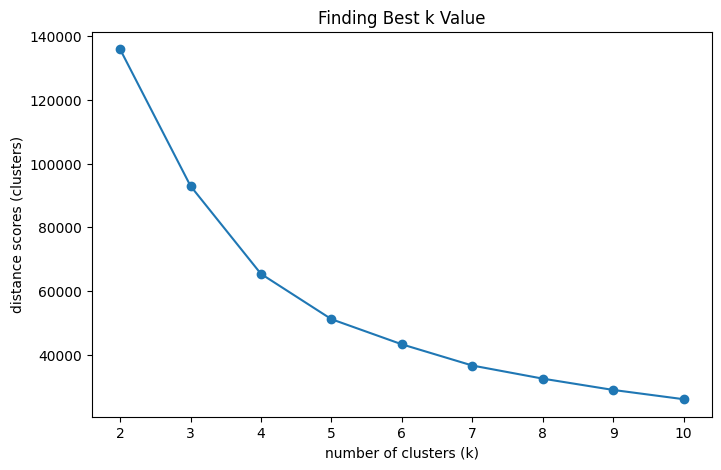

In [ ]:
# used different k values and calculated the sum of distances between a data point and its centroid for each cluster
# then summed all the results from each cluster

distance_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_scaled)
    distance_scores.append(kmeans.inertia_)

# plot average distances
plt.figure(figsize=(8, 5))
plt.plot(k_values, distance_scores, marker='o')
plt.xlabel("number of clusters (k)")
plt.ylabel("distance scores (clusters)")
plt.title("Finding Best k Value")
plt.show()

In [ ]:
# chose the best k based on the plot

k_best = 5

In [ ]:
# assigned each point to nearest centroid, updates them, and then repeats

km = KMeans(
    n_clusters= k_best,
    init='k-means++',
    n_init=10,
    random_state=42
)

kmeans_df['cluster'] = km.fit_predict(X_scaled)

print("\nCluster counts:")
print(kmeans_df['cluster'].value_counts().sort_index())


Cluster counts:
cluster
0    29109
1    24251
2    27288
3    25564
4    25411
Name: count, dtype: int64


In [ ]:
# converted centers back to original scale for latitude and longitude

center = scaler.inverse_transform(km.cluster_centers_)
center_df = pd.DataFrame(center, columns=['latitude_center', 'longitude_center'])
center_df['cluster'] = range(k_best)

print("\nCluster centers:")
print(center_df)


Cluster centers:
   latitude_center  longitude_center  cluster
0        41.878849        -87.642202        0
1        41.930636        -87.764441        1
2        41.745456        -87.612906        2
3        41.955633        -87.686716        3
4        41.801127        -87.708794        4


Text(0, 0.5, 'latitude')

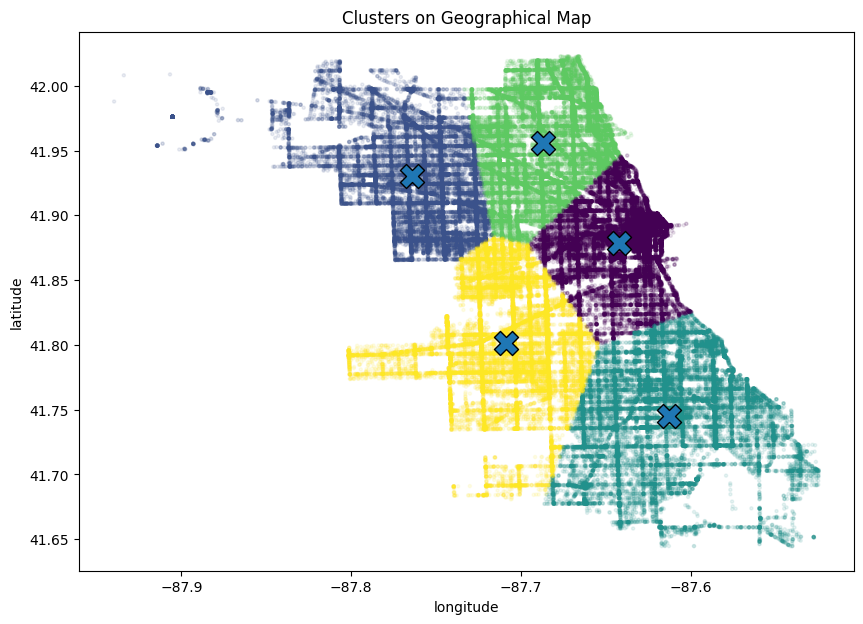

In [ ]:
# plot the clusters

plt.figure(figsize=(10, 7))
plt.scatter(
    kmeans_df['longitude'],
    kmeans_df['latitude'],
    c=kmeans_df['cluster'],
    alpha=0.1,
    s=5
)
plt.scatter(
    center_df['longitude_center'],
    center_df['latitude_center'],
    marker='X',
    s=300,
    edgecolor='black'
)
plt.title("Clusters on Geographical Map")
plt.xlabel("longitude")
plt.ylabel("latitude")

In [ ]:
# compare severity across clusters

print("average severity by cluster:")
print(kmeans_df.groupby('cluster')['severity_label'].mean().sort_values(ascending=False))
print()

print("crash counts by cluster:")
print(kmeans_df.groupby('cluster').size())
print()


print("fatal crash counts by cluster:")
print(kmeans_df[kmeans_df['severity_label'] == 2].groupby('cluster').size())
print()

average severity by cluster:
cluster
2    0.198256
4    0.164456
1    0.163127
0    0.150641
3    0.138985
Name: severity_label, dtype: float64

crash counts by cluster:
cluster
0    29109
1    24251
2    27288
3    25564
4    25411
dtype: int64

fatal crash counts by cluster:
cluster
0    18
1    19
2    35
3    11
4    22
dtype: int64



In [ ]:
# Section 4 - Apriori

In [ ]:
# create baskets using the crash data

from collections import Counter
from itertools import combinations

# use crashes with injury or fatality
apriori_df = df[df['severity_label'] >= 1].copy()

pattern_cols = [
    'weather_condition',
    'lighting_condition',
    'roadway_surface_cond',
    'traffic_control_device',
    'trafficway_type',
    'road_defect',
    'intersection_related_i',
    'hit_and_run_i',
    'first_crash_type'
]

pattern_cols = [col for col in pattern_cols if col in apriori_df.columns]

for col in pattern_cols:
    apriori_df[col] = apriori_df[col].fillna('Unsure')

list_of_crashes = []
for _, row in apriori_df.iterrows():
    basket = []

    for col in pattern_cols:
        basket.append(f"{col}={row[col]}")

    # add severity into basket
    basket.append(f"severity={row['severity_label']}")

    list_of_crashes.append(basket)

print("Num of baskets: ", len(list_of_crashes))
print("First basket: ")
print(list_of_crashes[0])

Num of baskets:  21381
First basket: 
['weather_condition=CLEAR', 'lighting_condition=DARKNESS, LIGHTED ROAD', 'roadway_surface_cond=DRY', 'traffic_control_device=NO CONTROLS', 'trafficway_type=DIVIDED - W/MEDIAN BARRIER', 'road_defect=NO DEFECTS', 'intersection_related_i=Unsure', 'hit_and_run_i=Y', 'first_crash_type=REAR END', 'severity=1']


In [ ]:
# support count: changes based on number of rules

s = 20
print("Support threshold:", s)

Support threshold: 20


In [ ]:
# apriori function
# returns counters and lists for single, pair, and triple itemsets

def frequent_itemsets(data, s):

    # count single items
    c1 = Counter()
    for d in data:
        for item in d:
            c1[item] += 1

    # keep frequent single items
    l1 = set()
    for item in c1:
        if c1[item] >= s:
            l1.add(item)

    # filter baskets to only frequent single items
    filtered_data = []
    for d in data:
        new_data = []
        for item in d:
            if item in l1:
                new_data.append(item)

        if len(new_data) >= 2:
            new_data.sort()
            filtered_data.append(new_data)

    # count pairs
    c2 = Counter()
    for d in filtered_data:
        for pair in combinations(d, 2):
            c2[pair] += 1

    # keep frequent pairs
    l2 = set()
    for pair in c2:
        if c2[pair] >= s:
            l2.add(pair)

    # count triples using Apriori pruning
    c3 = Counter()
    for d in filtered_data:
        if len(d) < 3:
            continue

        for t in combinations(d, 3):
            x, y, z = t

            pair1 = (x, y)
            pair2 = (x, z)
            pair3 = (y, z)

            if pair1 in l2 and pair2 in l2 and pair3 in l2:
                c3[t] += 1

    # keep frequent triples
    l3 = set()
    for triple in c3:
        if c3[triple] >= s:
            l3.add(triple)

    return c1, c2, c3, l1, l2, l3

In [ ]:
# get rules of pairs

def all_pair_rules(c1, c2, s):
    rules = []

    for pair in c2:
        support_ab = c2[pair]

        if support_ab < s:
            continue

        a, b = pair

        # compute the confidences
        confidence_ab = support_ab / c1[a]
        rules.append((confidence_ab, a, b, support_ab))

        confidence_ba = support_ab / c1[b]
        rules.append((confidence_ba, b, a, support_ab))

    # ranking the rules based on confidence
    rules.sort(key=lambda r: (-r[0], -r[3], r[1], r[2]))
    return rules

In [ ]:
# get rules of triples

def all_triple_rules(c2, c3, s):
    rules = []

    for triple in c3:
        support_xyz = c3[triple]

        if support_xyz < s:
            continue

        a, b, c = triple

        # compute the confidences
        if (a, b) in c2:
            confidence = support_xyz / c2[(a, b)]
            rules.append((confidence, a, b, c, support_xyz))

        if (a, c) in c2:
            confidence = support_xyz / c2[(a, c)]
            rules.append((confidence, a, c, b, support_xyz))

        if (b, c) in c2:
            confidence = support_xyz / c2[(b, c)]
            rules.append((confidence, b, c, a, support_xyz))

    # ranking the rules based on confidence
    rules.sort(key=lambda r: (-r[0], -r[4], r[1], r[2], r[3]))
    return rules

In [ ]:
# run frequent_itemsets function (apriori function) to get all frequent itemsets

c1, c2, c3, l1, l2, l3 = frequent_itemsets(list_of_crashes, s)

print("Number of frequent 1-itemsets:", len(l1))
print("Number of frequent 2-itemsets:", len(l2))
print("Number of frequent 3-itemsets:", len(l3))

Number of frequent 1-itemsets: 78
Number of frequent 2-itemsets: 1199
Number of frequent 3-itemsets: 6857


In [ ]:
# generate top pair rules that predict fatal crashes

pair_rules = all_pair_rules(c1, c2, s)

fatal_pair_rules = []
for rule in pair_rules:
    confidence, x, y, support_xy = rule
    if y == "severity=2":
        fatal_pair_rules.append(rule)


print("\nTop 10 pair rules predicting severity=2:")
for rule in fatal_pair_rules[:10]:
    confidence, x, y, support_xy = rule
    print(f"{x} -> {y} | confidence = {confidence:.4f} | support count = {support_xy}")

if len(fatal_pair_rules) == 0:
    print("No pair rules found for severity=2")


Top 10 pair rules predicting severity=2:
first_crash_type=FIXED OBJECT -> severity=2 | confidence = 0.0201 | support count = 21
first_crash_type=PEDESTRIAN -> severity=2 | confidence = 0.0113 | support count = 35
lighting_condition=DARKNESS, LIGHTED ROAD -> severity=2 | confidence = 0.0103 | support count = 60
traffic_control_device=NO CONTROLS -> severity=2 | confidence = 0.0063 | support count = 55
roadway_surface_cond=DRY -> severity=2 | confidence = 0.0052 | support count = 83
hit_and_run_i=Y -> severity=2 | confidence = 0.0051 | support count = 25
weather_condition=CLEAR -> severity=2 | confidence = 0.0051 | support count = 88
road_defect=NO DEFECTS -> severity=2 | confidence = 0.0049 | support count = 78
intersection_related_i=Unsure -> severity=2 | confidence = 0.0049 | support count = 62
hit_and_run_i=Unsure -> severity=2 | confidence = 0.0048 | support count = 78


In [ ]:
# generate top triple rules that predict fatal crashes

triple_rules = all_triple_rules(c2, c3, s)

fatal_triple_rules = []
for rule in triple_rules:
    confidence, x, y, z, support_xyz = rule
    if z == "severity=2":
        fatal_triple_rules.append(rule)

print("\nTop 10 triple rules predicting severity=2:")
for rule in fatal_triple_rules[:10]:
    confidence, x, y, z, support_xyz = rule
    print(f"({x}, {y}) -> {z} | confidence = {confidence:.4f} | support count = {support_xyz}")

if len(fatal_triple_rules) == 0:
    print("No triple rules found for severity=2")


Top 10 triple rules predicting severity=2:
(first_crash_type=FIXED OBJECT, hit_and_run_i=Unsure) -> severity=2 | confidence = 0.0204 | support count = 20
(first_crash_type=PEDESTRIAN, traffic_control_device=NO CONTROLS) -> severity=2 | confidence = 0.0181 | support count = 20
(lighting_condition=DARKNESS, LIGHTED ROAD, traffic_control_device=NO CONTROLS) -> severity=2 | confidence = 0.0139 | support count = 32
(first_crash_type=PEDESTRIAN, roadway_surface_cond=DRY) -> severity=2 | confidence = 0.0138 | support count = 31
(first_crash_type=PEDESTRIAN, weather_condition=CLEAR) -> severity=2 | confidence = 0.0125 | support count = 31
(first_crash_type=PEDESTRIAN, intersection_related_i=Unsure) -> severity=2 | confidence = 0.0124 | support count = 22
(lighting_condition=DARKNESS, LIGHTED ROAD, roadway_surface_cond=DRY) -> severity=2 | confidence = 0.0115 | support count = 48
(hit_and_run_i=Unsure, lighting_condition=DARKNESS, LIGHTED ROAD) -> severity=2 | confidence = 0.0115 | support cou